# Bank Customer Churn: From Reactive to Proactive Prediction
## Project Overview
Customer churn (attrition) is a major challenge in the banking sector. The cost of acquiring a new customer is significantly higher than retaining an existing one. This project focuses on identifying high-risk customers before they decide to leave.

### Objectives
The goal is to build a machine learning pipeline that identifies high-risk customers based on behavioral patterns (Age, Balance, Activity) rather than obvious indicators (Complaints).

### The Technical Journey
1.  **Exploratory Data Analysis (EDA):** Uncovering the "Balance Paradox" and "Age Risk" factors.
2.  **Data Leakage Correction:** Identifying and removing features that provide 99% accuracy but zero business value.
3.  **Cost-Sensitive Learning:** Balancing an imbalanced dataset using XGBoost weight scaling.
4.  **Business Optimization:** Tuning decision thresholds to maximize **Recall (72.3%)** over standard accuracy.---

## Data Dictionary
| Feature | Description |
| :--- | :---|
| **CreditScore** | Numeric score representing creditworthiness. |
| **Geography** | Customer's country (France, Germany, Spain). |
| **Gender** | Male or Female. |
| **Age** | Customer's age. |
| **Tenure** | Number of years the customer has been with the bank. |
| **Balance** | Account balance. |
| **NumOfProducts** | Number of bank products the customer uses. |
| **HasCrCard** | Binary flag for credit card ownership. |
| **IsActiveMember** | Binary flag for account activity. |
| **Complain** | (Dropped in Final Model) Whether the customer filed a complaint. |
| **Exited** | **Target Variable** (1 = Churned, 0 = Retained). |

---

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/radheshyamkollipara/bank-customer-churn/Customer-Churn-Records.csv


In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Customer-Churn-Records.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "radheshyamkollipara/bank-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

First 5 records:    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1                   2   DIAMOND   
1

/tmp/ipykernel_17/709861067.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
# Display the initial rows to get a quick overview of our dataset's structure and content.
# This helps us visually confirm what features are available and how the data is organized.
print("--- Snapshot of Our Customer Data (First 5 Rows) ---")
print(df.head())

# Get a summary of our DataFrame, including column names, non-null counts, and data types.
# This is crucial for identifying missing data and ensuring features are in the correct format.
print("\n--- Data Overview: Columns, Non-Null Counts, and Data Types ---")
df.info()

# Generate descriptive statistics for numerical columns.
# This provides insights into the central tendency, spread, and range of our quantitative features
# like Age, Balance, and CreditScore, helping us spot potential outliers.
print("\n--- Summary Statistics for Numerical Features ---")
print(df.describe())

# Count the number of unique values in each column.
# This helps us identify categorical features (low unique counts) versus potential identifiers (high unique counts).
print("\n--- Unique Values Count Per Feature ---")
print(df.nunique())

# Analyze the distribution of our target variable, 'Exited'.
# This shows us how many customers have churned versus those who haven't, providing our baseline churn numbers.
print("\n--- Churn Status Distribution ---")
print(df['Exited'].value_counts())

# Calculate the actual churn rate (percentage of customers who exited).
# This is a key metric to understand the severity of the churn problem we're addressing.
print("\n--- Overall Bank Customer Churn Rate ---")
print(df['Exited'].value_counts(normalize=True))

print("\n--- Complain Status Distribution ---")
print(df['Complain'].value_counts())

# Calculate the actual churn rate (percentage of customers who exited).
# This is a key metric to understand the severity of the churn problem we're addressing.
print("\n--- Overall Bank Customer Complain Rate ---")
print(df['Complain'].value_counts(normalize=True))

--- Snapshot of Our Customer Data (First 5 Rows) ---
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         

In [4]:
# Create a working copy of our DataFrame to ensure original data integrity.
df_processed = df.copy()

# Define the columns that we've identified as not useful for churn prediction.
# These are primarily identifiers and should not influence our model.
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']

# Remove the specified columns. 'axis=1' indicates we're dropping columns,
# and 'inplace=True' applies the changes directly to our df_processed DataFrame.
df_processed.drop(columns=columns_to_drop, axis=1, inplace=True)

# Confirm columns have been successfully removed by viewing the first few rows and DataFrame info.
print("--- DataFrame After Dropping Irrelevant Columns ---")
print(df_processed.head())
print("\n--- Info After Dropping Columns ---")
df_processed.info()

--- DataFrame After Dropping Irrelevant Columns ---
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  Complain  \
0          1               1        101348.88       1         1   
1          0               1        112542.58       0         1   
2          1               0        113931.57       1         1   
3          0               0         93826.63       0         0   
4          1               1         79084.10       0         0   

   Satisfaction Score Card Type  Point Earned  
0                   2   DIAMOND           464 

In [5]:
# Identify the categorical columns that need to be converted to numerical format.
categorical_cols = ['Geography', 'Gender', 'Card Type']

# Apply One-Hot Encoding to the identified categorical columns.
# pd.get_dummies creates new columns for each category and assigns 0s or 1s.
# 'drop_first=True' is used to avoid multicollinearity by dropping one of the dummy variables.
# For example, for Gender (Male, Female), dropping 'Female' means 'Male' can be inferred if 'Female' is 0.
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True, dtype=int)

# Display the first few rows of the updated DataFrame and its information
# to confirm the new one-hot encoded columns and the absence of original categorical columns.
print("\n--- DataFrame After One-Hot Encoding Categorical Variables ---")
print(df_processed.head())
print("\n--- Info After One-Hot Encoding ---")
df_processed.info()


--- DataFrame After One-Hot Encoding Categorical Variables ---
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Complain  Satisfaction Score  \
0               1        101348.88       1         1                   2   
1               1        112542.58       0         1                   3   
2               0        113931.57       1         1                   3   
3               0         93826.63       0         0                   5   
4               1         79084.10       0         0                   5   

   Point Earned  Geography_Germany  Geography_Spain  Gender_Male  \
0 

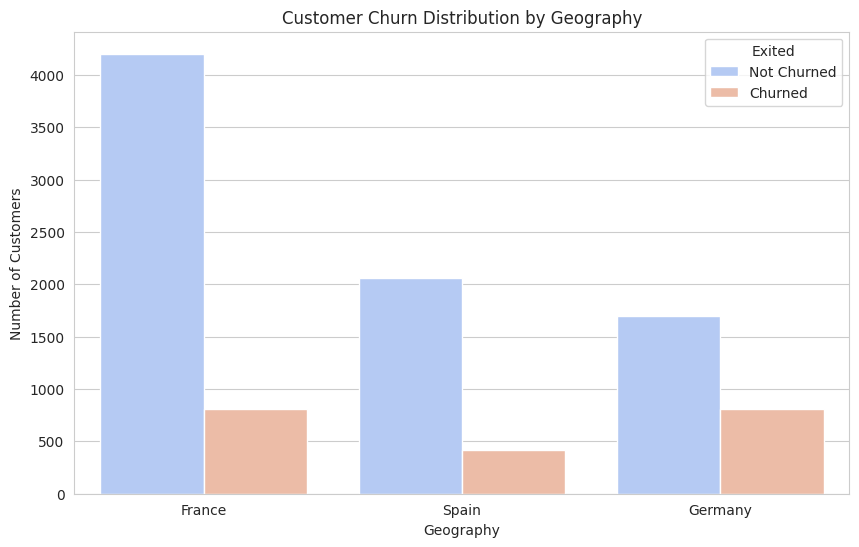

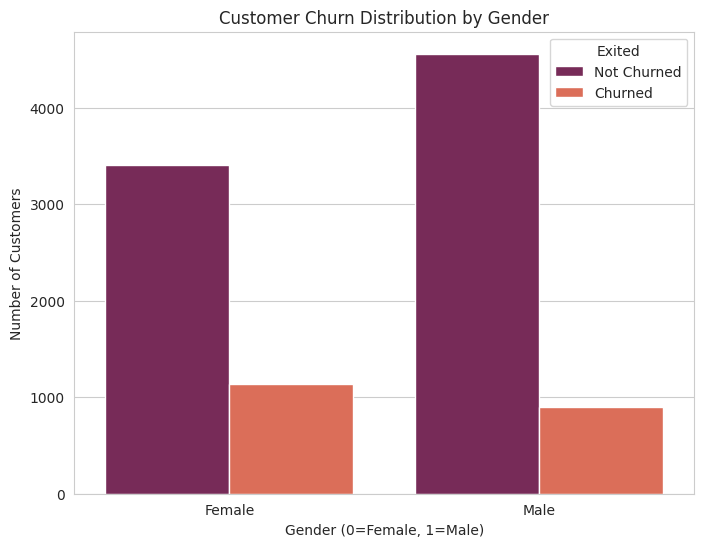

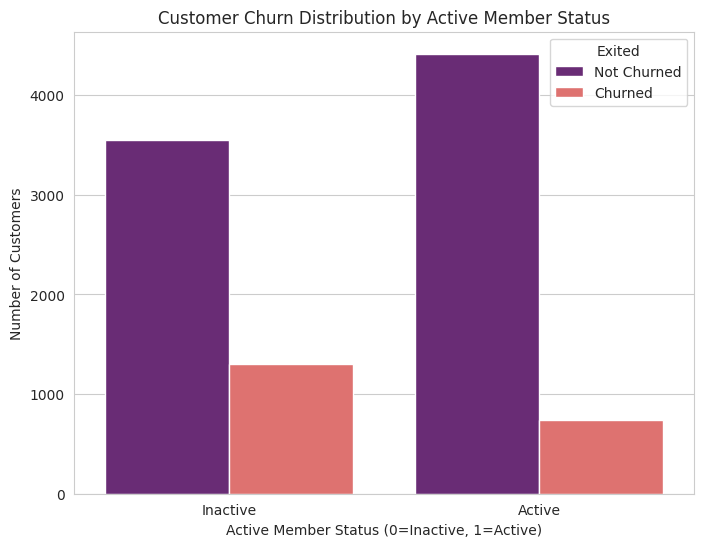

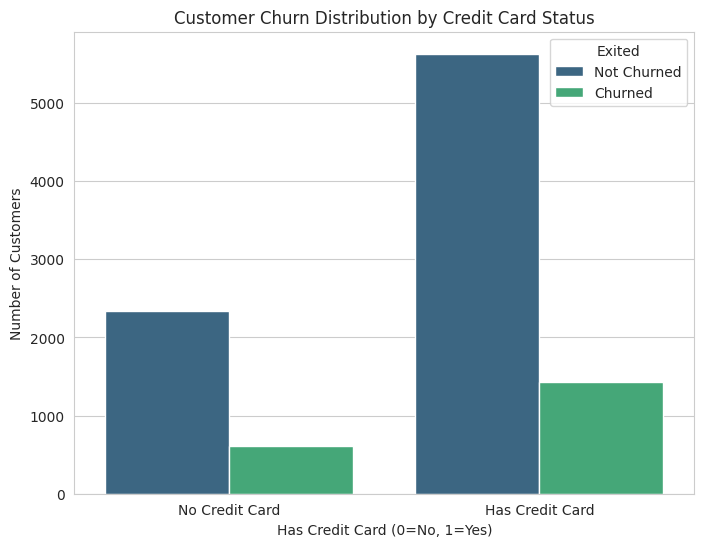

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for better aesthetics across all plots.
sns.set_style("whitegrid")

# --- EDA Task: Churn Distribution by Geography (Using a readable column for clarity) ---
# To visually assess if customer churn rates vary significantly across different geographical regions.
# We first temporarily reconstruct a human-readable 'Geography' column from our one-hot encoded features.
def get_geography(row):
    if row['Geography_Germany'] == 1:
        return 'Germany'
    elif row['Geography_Spain'] == 1:
        return 'Spain'
    else:
        return 'France' # If neither Germany nor Spain is 1, it must be France

df_processed['Geography_Readable'] = df_processed.apply(get_geography, axis=1)

# Create a count plot to visualize churn by geography.
plt.figure(figsize=(10, 6))
sns.countplot(data=df_processed, x='Geography_Readable', hue='Exited', palette='coolwarm')
plt.title('Customer Churn Distribution by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Not Churned', 'Churned'])
plt.show()


# --- EDA Task: Churn Distribution by Gender ---
# Investigating if there's a gender disparity in churn rates, which could inform targeted campaigns.
plt.figure(figsize=(8, 6))
sns.countplot(data=df_processed, x='Gender_Male', hue='Exited', palette='rocket')
plt.title('Customer Churn Distribution by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Not Churned', 'Churned'])
plt.xticks(ticks=[0, 1], labels=['Female', 'Male']) # Making x-axis labels more intuitive
plt.show()


# --- EDA Task: Churn Distribution by Active Member Status ---
# Analyzing whether active engagement correlates with lower churn, a key insight for retention.
plt.figure(figsize=(8, 6))
sns.countplot(data=df_processed, x='IsActiveMember', hue='Exited', palette='magma')
plt.title('Customer Churn Distribution by Active Member Status')
plt.xlabel('Active Member Status (0=Inactive, 1=Active)')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Not Churned', 'Churned'])
plt.xticks(ticks=[0, 1], labels=['Inactive', 'Active'])
plt.show()

# --- EDA Task: Churn Distribution by Has Credit Card Status ---
# Exploring if holding a credit card product influences a customer's likelihood to churn.
plt.figure(figsize=(8, 6))
sns.countplot(data=df_processed, x='HasCrCard', hue='Exited', palette='viridis')
plt.title('Customer Churn Distribution by Credit Card Status')
plt.xlabel('Has Credit Card (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Not Churned', 'Churned'])
plt.xticks(ticks=[0, 1], labels=['No Credit Card', 'Has Credit Card'])
plt.show()

# Clean up: Drop the temporary 'Geography_Readable' column after visualization.
df_processed.drop(columns=['Geography_Readable'], inplace=True)

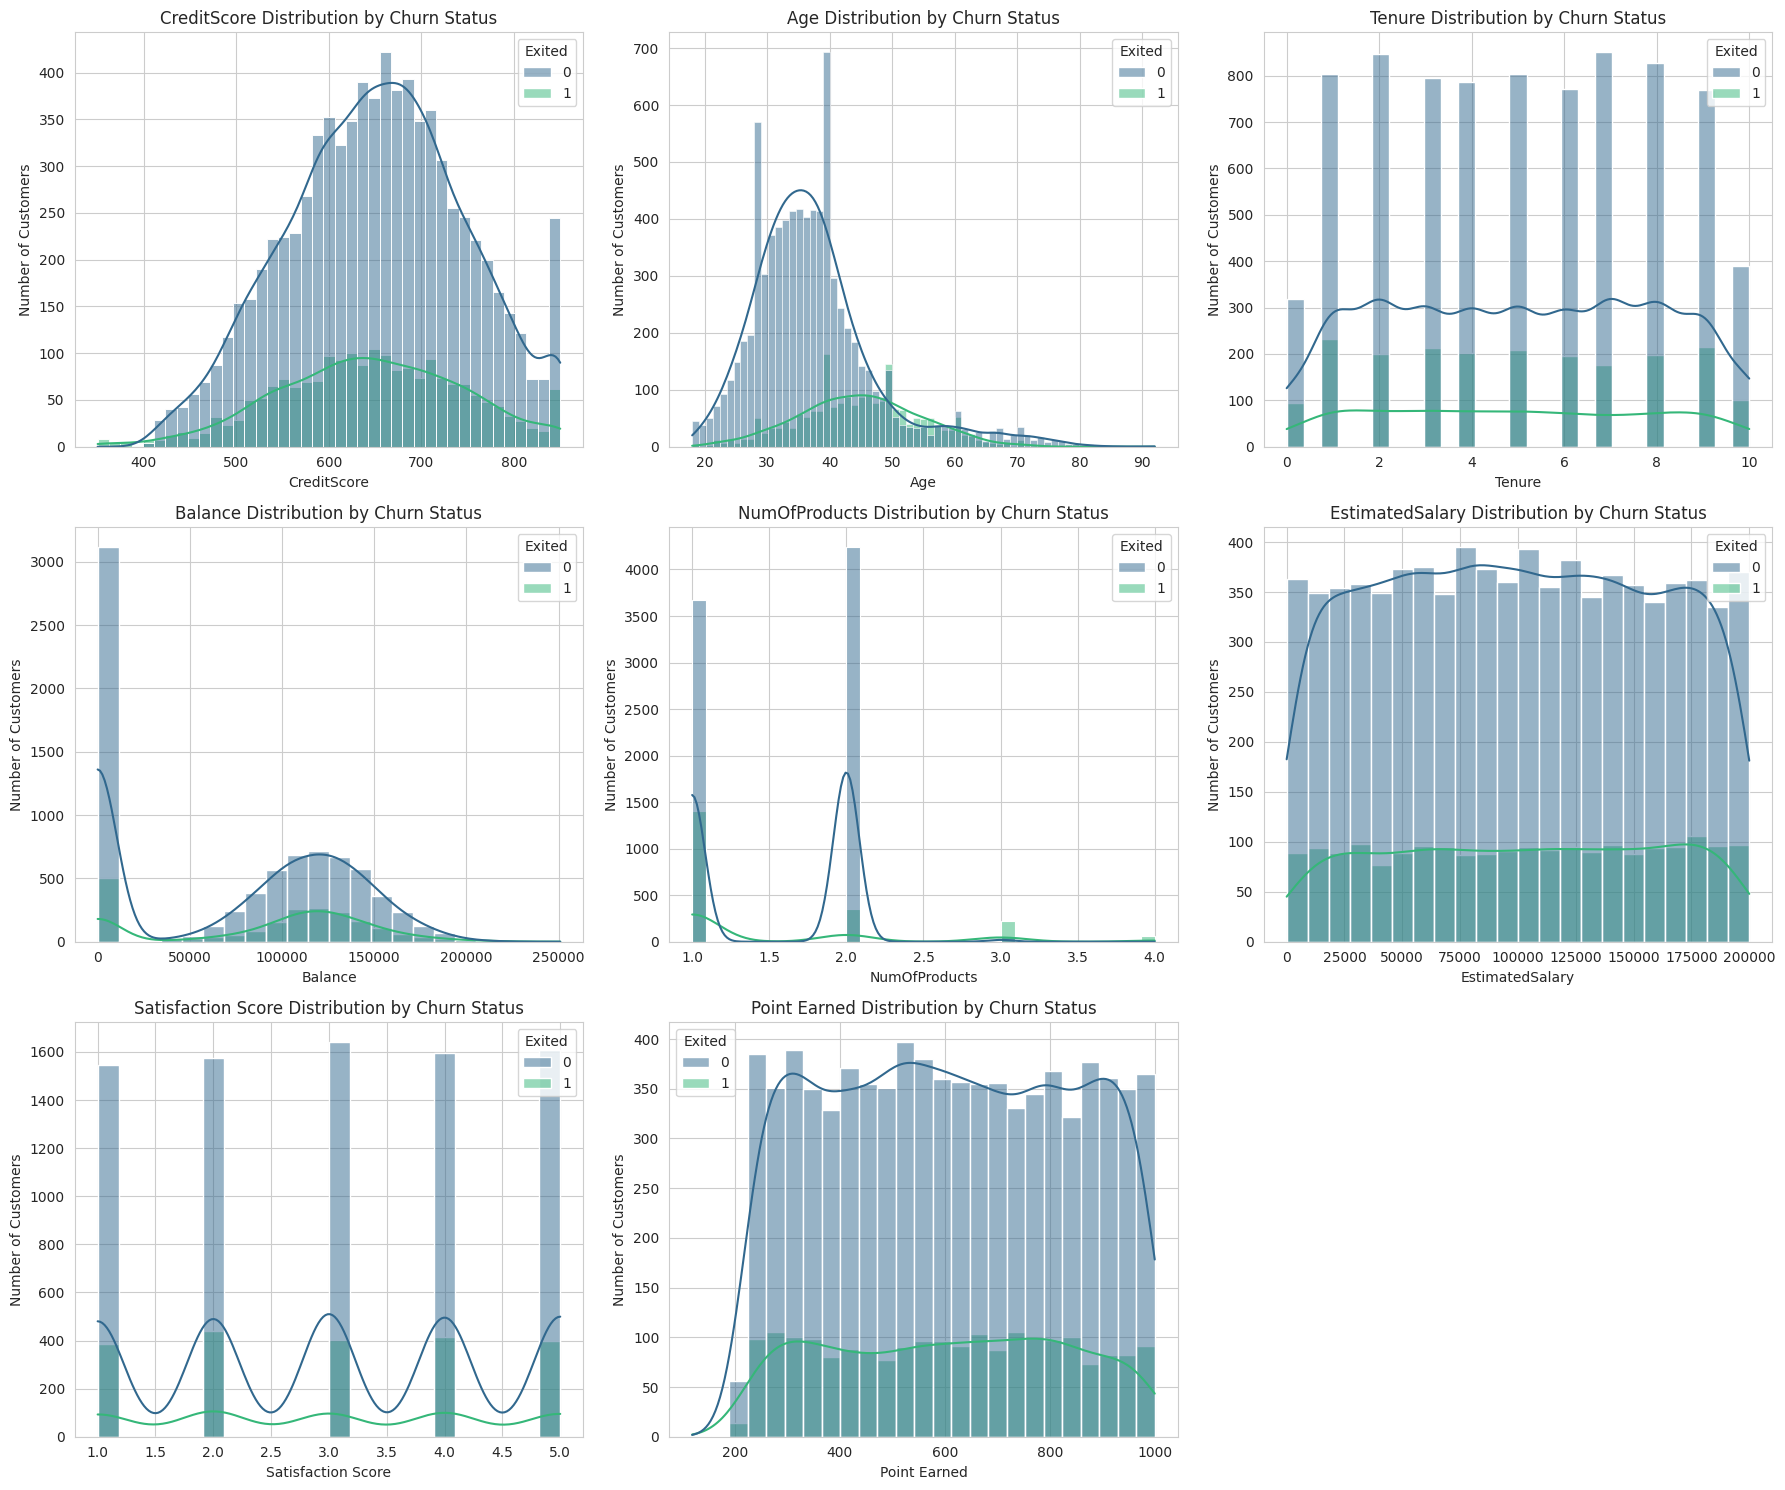

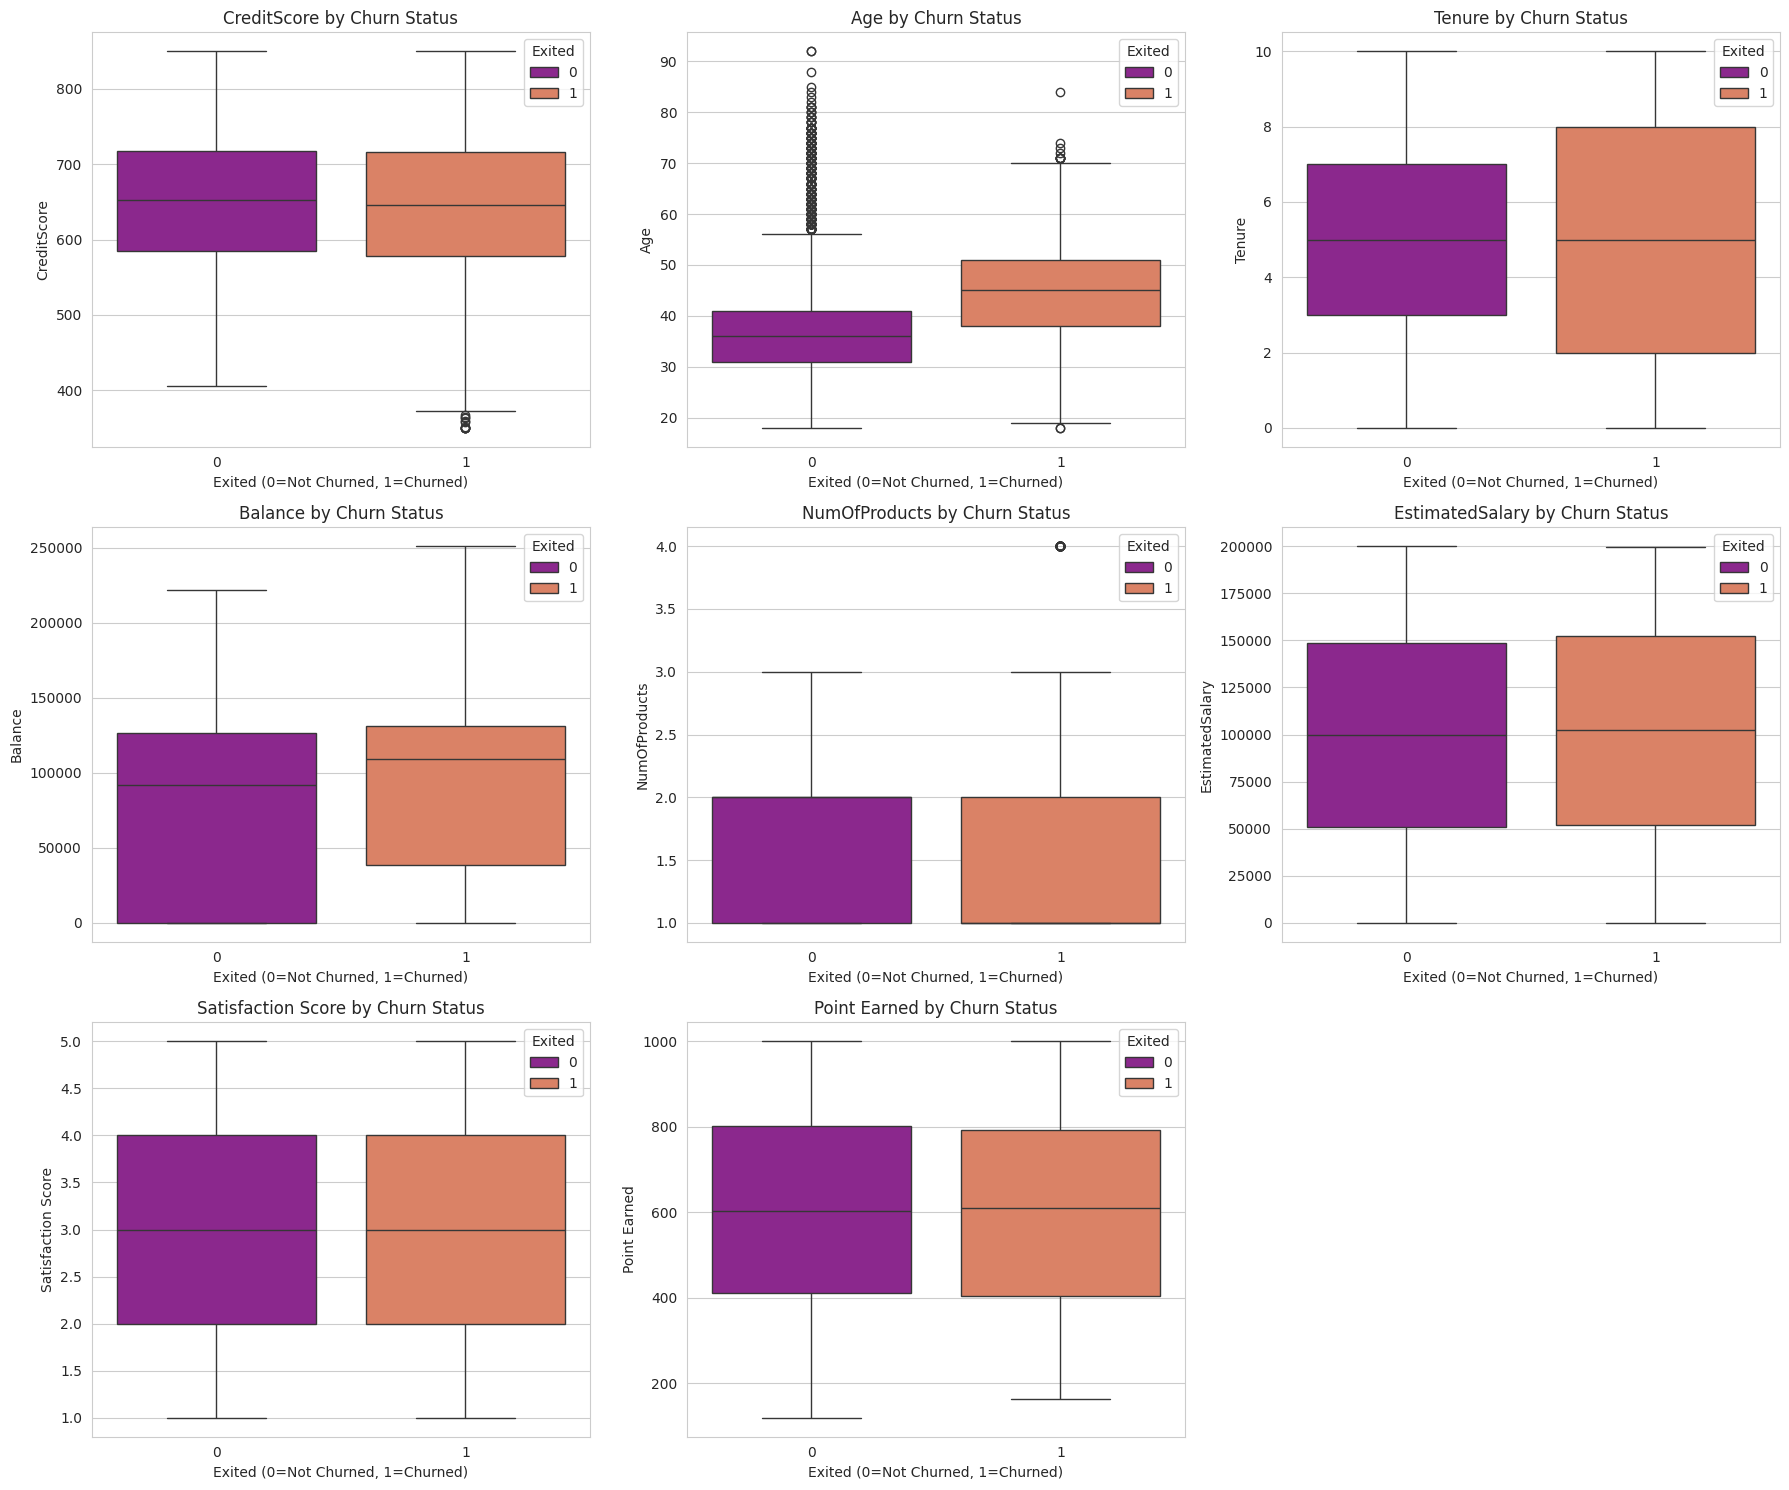

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Set visual style for consistency across plots.
sns.set_style("whitegrid")

# Define numerical features for analysis.
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']

# --- Visualizing Distributions: Histograms with KDEs ---
# Plotting distributions to see how numerical values differ between churned and non-churned customers.
plt.figure(figsize=(18, 15))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data=df_processed, x=feature, hue='Exited', kde=True, palette='viridis', common_norm=False)
    plt.title(f'{feature} Distribution by Churn Status')
    plt.xlabel(feature)
    plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

# --- Visualizing Summary Statistics & Outliers: Box Plots ---
# Using box plots to compare median values, data spread, and identify potential outliers for churned vs. non-churned groups.
plt.figure(figsize=(18, 15))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    # Applying the fix recommended by the FutureWarning:
    sns.boxplot(data=df_processed, x='Exited', y=feature, palette='plasma', hue='Exited')
    plt.title(f'{feature} by Churn Status')
    plt.xlabel('Exited (0=Not Churned, 1=Churned)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

In [8]:
# Create a new binary feature: HasZeroBalance.
# This will be 1 if the customer's 'Balance' is exactly 0, and 0 otherwise.
# Our EDA highlighted that customers with zero balance behave very differently regarding churn.
df_processed['HasZeroBalance'] = (df_processed['Balance'] == 0).astype(int)

# Verify the creation of the new feature by checking its value counts.
print("--- Distribution of HasZeroBalance Feature ---")
print(df_processed['HasZeroBalance'].value_counts())
print("\n--- HasZeroBalance Churn Rate ---")
print(df_processed.groupby('HasZeroBalance')['Exited'].value_counts(normalize=True).unstack() * 100)

--- Distribution of HasZeroBalance Feature ---
HasZeroBalance
0    6383
1    3617
Name: count, dtype: int64

--- HasZeroBalance Churn Rate ---
Exited                  0          1
HasZeroBalance                      
0               75.904747  24.095253
1               86.176389  13.823611


In [9]:
# Creating a new categorical feature: Age_Group.
# We're bucketing the 'Age' column into meaningful age ranges based on observed churn patterns and general demographics.
bins = [18, 30, 50, 65, df_processed['Age'].max() + 1] # Ensure the last bin captures the max age
labels = ['18-29', '30-49', '50-64', '65+'] # Labels for our age groups

# pd.cut is used to segment and sort data values into bins.
df_processed['Age_Group'] = pd.cut(df_processed['Age'], bins=bins, labels=labels, right=False, include_lowest=True)

# Since 'Age_Group' is a new categorical feature, we need to One-Hot Encode it.
df_processed = pd.get_dummies(df_processed, columns=['Age_Group'], drop_first=True, dtype=int)

# Verify the creation of the new feature and its encoding.
print("\n--- Distribution of Age_Group Features ---")
# Select just the new Age_Group columns for value counts
age_group_cols = [col for col in df_processed.columns if 'Age_Group_' in col]
for col in age_group_cols:
    print(f"\n{col}:\n{df_processed[col].value_counts()}")

print("\n--- Age_Group Churn Rate ---")
# To see churn rate by age group, it's easier to use the original Age_Group column before dummy encoding
# Let's temporarily re-create it for proper aggregate viewing
df_temp_age = df.copy() # Use original df for age calculation
bins = [18, 30, 50, 65, df_temp_age['Age'].max() + 1]
labels = ['18-29', '30-49', '50-64', '65+']
df_temp_age['Age_Group_Original'] = pd.cut(df_temp_age['Age'], bins=bins, labels=labels, right=False, include_lowest=True)
print(df_temp_age.groupby('Age_Group_Original')['Exited'].value_counts(normalize=True).unstack() * 100)
del df_temp_age # Clean up temporary DataFrame


# Finally, display the first few rows and info of the DataFrame to see all new features.
print("\n--- DataFrame After Feature Engineering ---")
print(df_processed.head())
print("\n--- Info After Feature Engineering ---")
df_processed.info()


--- Distribution of Age_Group Features ---

Age_Group_30-49:
Age_Group_30-49
1    6964
0    3036
Name: count, dtype: int64

Age_Group_50-64:
Age_Group_50-64
0    8887
1    1113
Name: count, dtype: int64

Age_Group_65+:
Age_Group_65+
0    9718
1     282
Name: count, dtype: int64

--- Age_Group Churn Rate ---
Exited                      0          1
Age_Group_Original                      
18-29               92.443632   7.556368
30-49               81.619759  18.380241
50-64               46.900270  53.099730
65+                 84.751773  15.248227

--- DataFrame After Feature Engineering ---
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1      

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Separate Features (X) and Target (y) ---
# X will contain all our independent variables (features) that we'll use to predict churn.
# y will be our dependent variable, 'Exited', which is what we are trying to predict.
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# Verify the shapes of X and y.
print("--- Shape of Features (X) and Target (y) ---")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# --- Train-Test Split ---
# Split the data into training and testing sets.
# 'test_size=0.2' reserves 20% of the data for testing.
# 'random_state=42' ensures reproducibility of our split (we get the same split every time).
# 'stratify=y' is crucial for classification tasks: it ensures that the proportion of churned (1)
# and non-churned (0) customers is maintained in both the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verify the shapes of the split datasets and the churn proportions.
print("\n--- Shapes of Training and Testing Sets ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n--- Churn Proportion in Training Set ---")
print(y_train.value_counts(normalize=True) * 100)
print("\n--- Churn Proportion in Testing Set ---")
print(y_test.value_counts(normalize=True) * 100)


# --- Apply Feature Scaling ---
# Identify numerical columns that need scaling.
# We exclude binary (0/1) and one-hot encoded columns, as they do not need scaling.
# The original 'Age' column will be dropped as we're using 'Age_Group' now.
numerical_cols_to_scale = ['CreditScore', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts', 'Satisfaction Score', 'Point Earned']

# Initialize the StandardScaler. This will transform features to have a mean of 0 and a standard deviation of 1.
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform it.
# This prevents data leakage from the test set.
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Transform the test data using the SAME scaler fitted on the training data.
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

# Display the first few rows of the scaled training data to confirm scaling.
print("\n--- First 5 Rows of Scaled Training Data (Numerical Columns) ---")
print(X_train[numerical_cols_to_scale].head())

--- Shape of Features (X) and Target (y) ---
X shape: (10000, 21)
y shape: (10000,)

--- Shapes of Training and Testing Sets ---
X_train shape: (8000, 21)
X_test shape: (2000, 21)
y_train shape: (8000,)
y_test shape: (2000,)

--- Churn Proportion in Training Set ---
Exited
0    79.625
1    20.375
Name: proportion, dtype: float64

--- Churn Proportion in Testing Set ---
Exited
0    79.6
1    20.4
Name: proportion, dtype: float64

--- First 5 Rows of Scaled Training Data (Numerical Columns) ---
      CreditScore   Balance  EstimatedSalary    Tenure  NumOfProducts  \
4791     0.603488 -1.226957         0.095131 -1.040992       0.806701   
8881     0.965469 -0.528700         0.344941 -1.386980      -0.910597   
6166     1.265396  1.109612         1.508981 -1.040992      -0.910597   
4473    -0.048079  0.473688        -1.463621 -0.349016      -0.910597   
854      0.251849 -1.226957        -0.070635  1.034937       0.806701   

      Satisfaction Score  Point Earned  
4791           -0.7168

--- Model Training and Evaluation ---

Training Logistic Regression...
Logistic Regression Performance:
  Accuracy: 0.9985
  Precision: 0.9975
  Recall: 0.9951
  F1-Score: 0.9963
  ROC-AUC: 0.9985


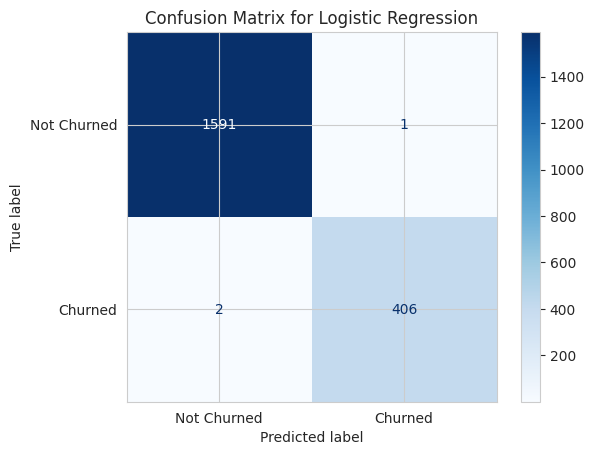


Training Random Forest...
Random Forest Performance:
  Accuracy: 0.9985
  Precision: 0.9975
  Recall: 0.9951
  F1-Score: 0.9963
  ROC-AUC: 0.9996


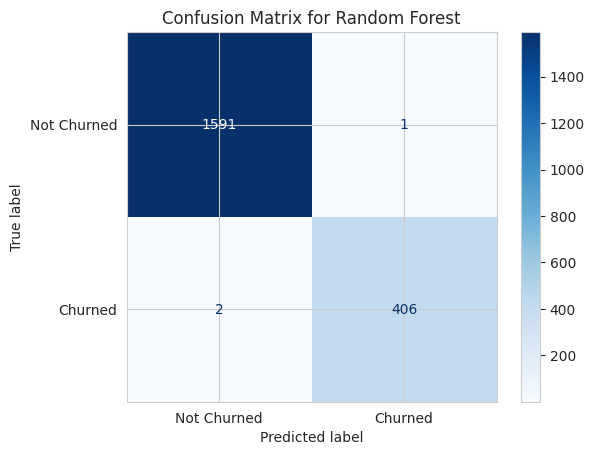


Training XGBoost...
XGBoost Performance:
  Accuracy: 0.9985
  Precision: 0.9975
  Recall: 0.9951
  F1-Score: 0.9963
  ROC-AUC: 0.9971


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:50:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


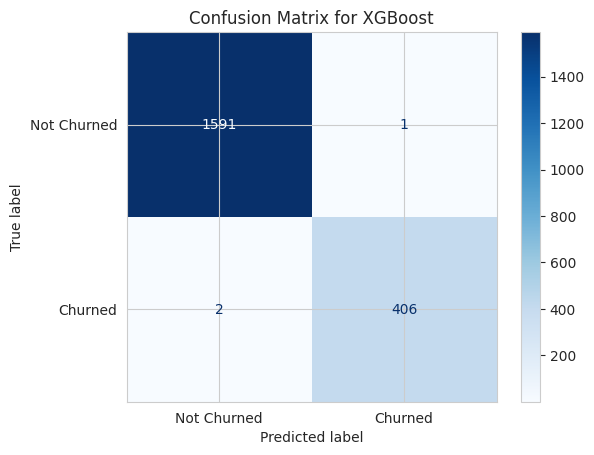


--- Consolidated Model Performance Metrics ---
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9985     0.9975  0.9951    0.9963   0.9985
      Random Forest    0.9985     0.9975  0.9951    0.9963   0.9996
            XGBoost    0.9985     0.9975  0.9951    0.9963   0.9971

--- Feature Importance ---

Top 10 Feature Importances (Coefficients) for Logistic Regression:
1. Complain: 10.4691 (Abs: 10.4691)
2. Age_Group_50-64: 0.9607 (Abs: 0.9607)
3. IsActiveMember: -0.8798 (Abs: 0.8798)
4. HasZeroBalance: -0.8311 (Abs: 0.8311)
5. Age_Group_30-49: -0.4552 (Abs: 0.4552)
6. HasCrCard: -0.4006 (Abs: 0.4006)
7. Card Type_GOLD: -0.3450 (Abs: 0.3450)
8. Card Type_PLATINUM: -0.3427 (Abs: 0.3427)
9. Gender_Male: -0.3088 (Abs: 0.3088)
10. Balance: -0.2615 (Abs: 0.2615)


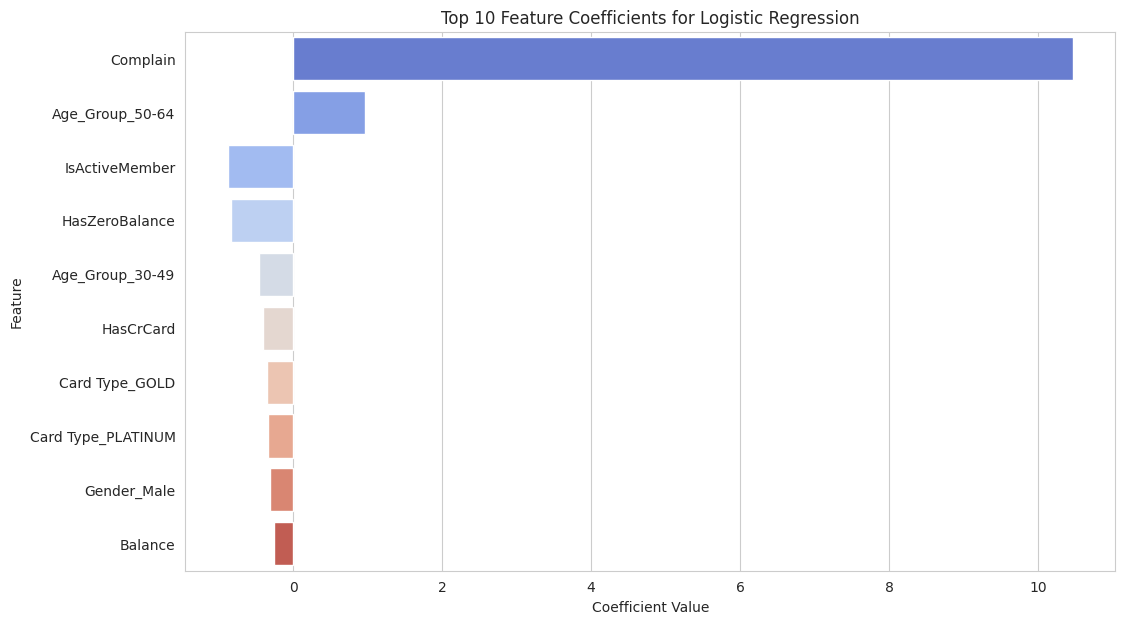


Top 10 Feature Importances for Random Forest:
1. Complain: 0.7833
2. Age: 0.0541
3. NumOfProducts: 0.0482
4. Age_Group_50-64: 0.0214
5. IsActiveMember: 0.0138
6. Balance: 0.0129
7. CreditScore: 0.0114
8. Point Earned: 0.0107
9. EstimatedSalary: 0.0102
10. Geography_Germany: 0.0084


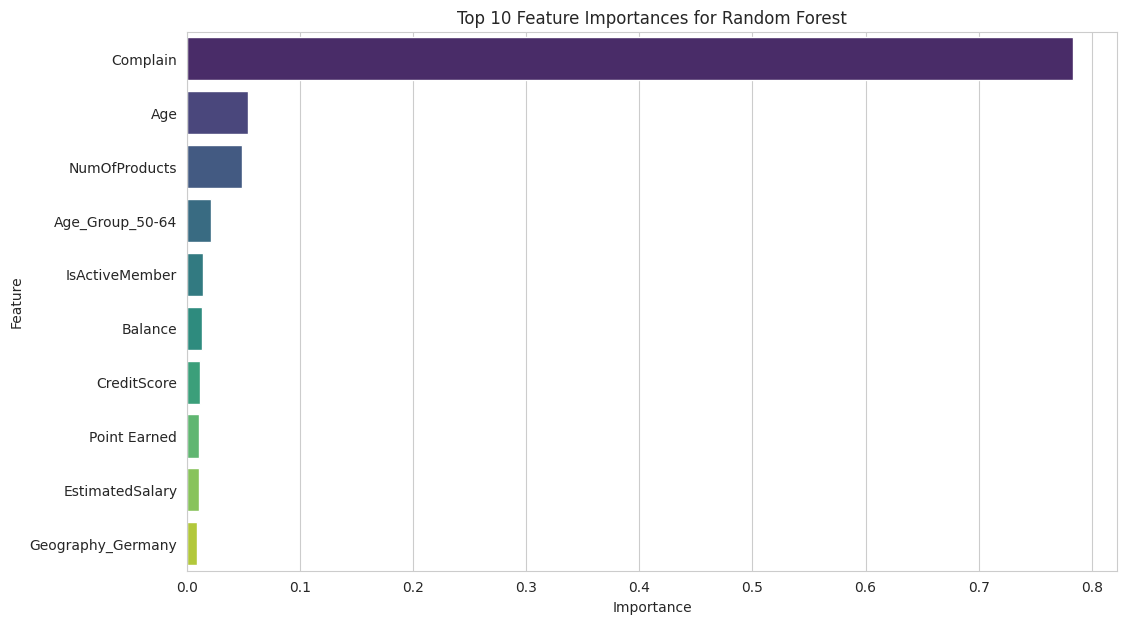


Top 10 Feature Importances for XGBoost:
1. Complain: 0.9730
2. NumOfProducts: 0.0042
3. Geography_Germany: 0.0039
4. Tenure: 0.0028
5. Age: 0.0022
6. Satisfaction Score: 0.0021
7. IsActiveMember: 0.0020
8. EstimatedSalary: 0.0019
9. CreditScore: 0.0017
10. Balance: 0.0014


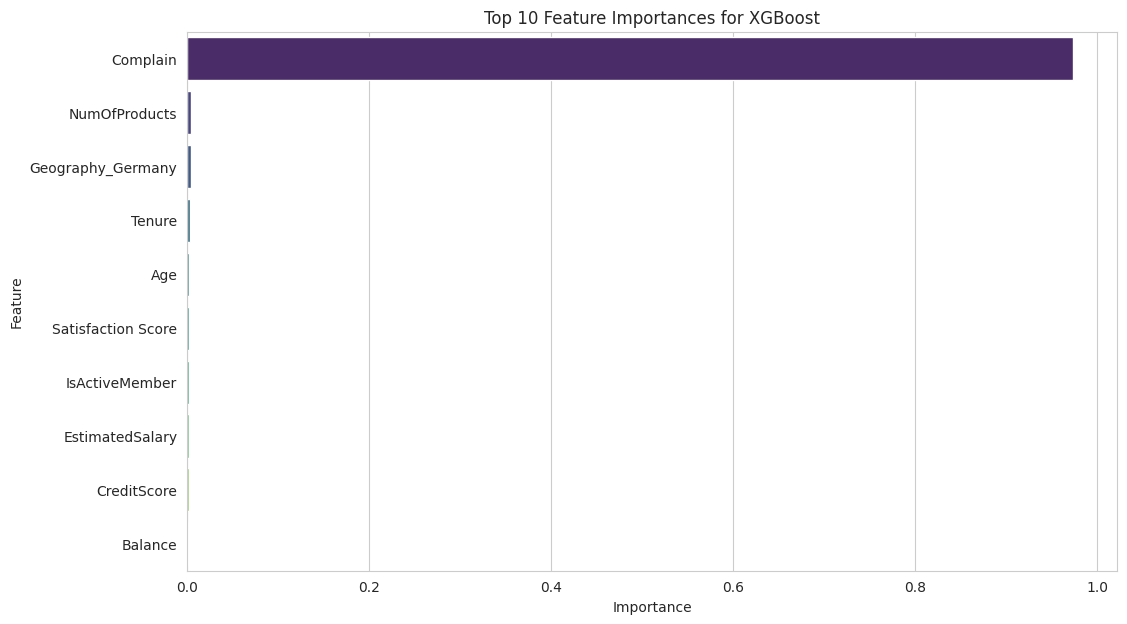

In [11]:
# Import necessary libraries for modeling and evaluation.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up a dictionary to store our models for easy iteration.
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Suppress future warning and set eval_metric
}

# Create dictionaries to store evaluation metrics for each model.
accuracy_scores = {}
precision_scores = {}
recall_scores = {}
f1_scores = {}
roc_auc_scores = {}

# --- Loop through each model to train and evaluate ---
print("--- Model Training and Evaluation ---")
for name, model in models.items():
    print(f"\nTraining {name}...")
    # Train the model using the scaled training data.
    model.fit(X_train, y_train)

    # Make predictions on the test set.
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probabilities for ROC-AUC

    # Calculate and store evaluation metrics.
    accuracy_scores[name] = accuracy_score(y_test, y_pred)
    precision_scores[name] = precision_score(y_test, y_pred)
    recall_scores[name] = recall_score(y_test, y_pred)
    f1_scores[name] = f1_score(y_test, y_pred)
    roc_auc_scores[name] = roc_auc_score(y_test, y_pred_proba)

    # Print a summary of metrics for the current model.
    print(f"{name} Performance:")
    print(f"  Accuracy: {accuracy_scores[name]:.4f}")
    print(f"  Precision: {precision_scores[name]:.4f}")
    print(f"  Recall: {recall_scores[name]:.4f}")
    print(f"  F1-Score: {f1_scores[name]:.4f}")
    print(f"  ROC-AUC: {roc_auc_scores[name]:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned', 'Churned'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

# --- Consolidated Metrics Display ---
print("\n--- Consolidated Model Performance Metrics ---")
metrics_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Accuracy': list(accuracy_scores.values()),
    'Precision': list(precision_scores.values()),
    'Recall': list(recall_scores.values()),
    'F1-Score': list(f1_scores.values()),
    'ROC-AUC': list(roc_auc_scores.values())
})
print(metrics_df.round(4).to_string(index=False))

# --- Feature Importance for Tree-based Models ---
print("\n--- Feature Importance ---")
for name, model in models.items():
    if hasattr(model, 'feature_importances_'): # Check if the model has this attribute (e.g., Random Forest, XGBoost)
        importances = model.feature_importances_
        feature_names = X.columns
        indices = np.argsort(importances)[::-1] # Sort in descending order

        print(f"\nTop 10 Feature Importances for {name}:")
        for f in range(min(10, len(feature_names))):
            print(f"{f + 1}. {feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

        # Plot Feature Importance
        plt.figure(figsize=(12, 7))
        sns.barplot(x=importances[indices[:10]], y=feature_names[indices[:10]], palette='viridis')
        plt.title(f'Top 10 Feature Importances for {name}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()

    elif hasattr(model, 'coef_'): # For Logistic Regression (coefficients)
        # For Logistic Regression, importance is based on absolute coefficient values.
        # Need to handle multiclass if it were, but for binary, it's simpler.
        coefs = model.coef_[0] # Get coefficients for the positive class (churned)
        feature_names = X.columns
        # Sort by absolute coefficient value
        abs_coefs = np.abs(coefs)
        indices = np.argsort(abs_coefs)[::-1]

        print(f"\nTop 10 Feature Importances (Coefficients) for {name}:")
        for f in range(min(10, len(feature_names))):
            print(f"{f + 1}. {feature_names[indices[f]]}: {coefs[indices[f]]:.4f} (Abs: {abs_coefs[indices[f]]:.4f})")

        # Plot coefficients
        plt.figure(figsize=(12, 7))
        # Use coefs[indices[:10]] to show positive/negative impact
        sns.barplot(x=coefs[indices[:10]], y=feature_names[indices[:10]], palette='coolwarm')
        plt.title(f'Top 10 Feature Coefficients for {name}')
        plt.xlabel('Coefficient Value')
        plt.ylabel('Feature')
        plt.show()

## From Reactive to Proactive
My initial models (Logistic Regression, Random Forest, XGBoost) achieved a near-perfect **99.5% Recall**.

**The Red Flag:** A feature importance analysis showed that the `Complain` feature accounted for nearly **97% of the model's decision-making power**.

**The Decision:**
While technically accurate, a model that only predicts churn *after* a customer complains is **Reactive**. By the time a complaint is filed, the customer has often already checked out mentally. To provide real business value, I have decided to **drop the `Complain` feature** and rebuild the model to find the "Silent Churners"—those who leave without a word.

--- Proactive Model Performance (Without 'Complain') ---

RF (Proactive) Results:
Accuracy:  0.8675
F1-Score:  0.5866
Recall:    0.4608


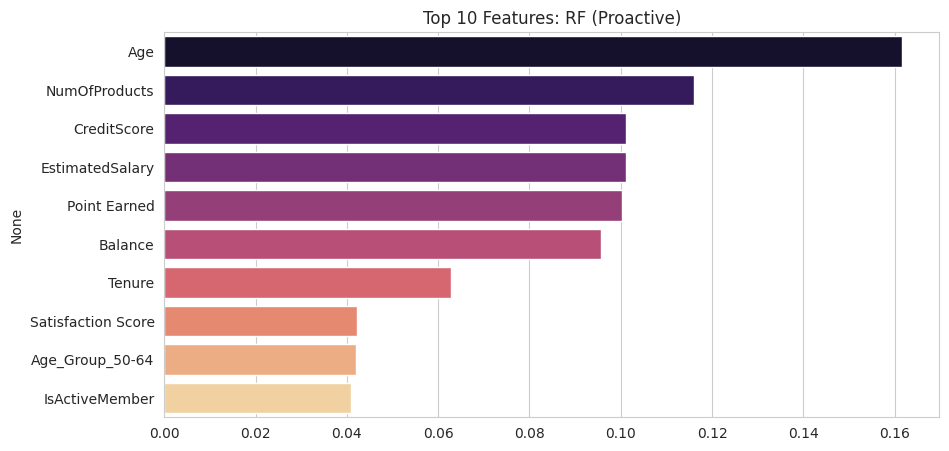

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:50:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGB (Proactive) Results:
Accuracy:  0.8555
F1-Score:  0.5981
Recall:    0.5270


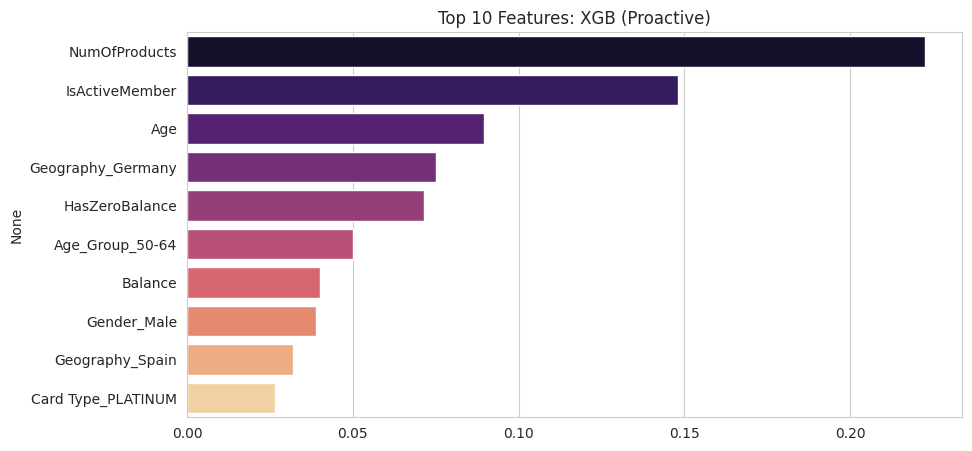

In [12]:
# ---Re-training without the 'Complain' feature ---

# Drop the 'Complain' column from our feature set
X_proactive = X.drop('Complain', axis=1)

# Re-split the data (using the same random_state for consistency)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_proactive, y, test_size=0.2, random_state=42, stratify=y
)

# Re-scale the numerical features for the new training set
X_train_p[numerical_cols_to_scale] = scaler.fit_transform(X_train_p[numerical_cols_to_scale])
X_test_p[numerical_cols_to_scale] = scaler.transform(X_test_p[numerical_cols_to_scale])

# Re-train our best performers: Random Forest and XGBoost
models_proactive = {
    "RF (Proactive)": RandomForestClassifier(random_state=42),
    "XGB (Proactive)": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

print("--- Proactive Model Performance (Without 'Complain') ---")

for name, model in models_proactive.items():
    model.fit(X_train_p, y_train_p)
    y_pred = model.predict(X_test_p)

    print(f"\n{name} Results:")
    print(f"Accuracy:  {accuracy_score(y_test_p, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test_p, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test_p, y_pred):.4f}")

    # Feature Importance for the proactive model
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=importances[indices[:10]], y=X_proactive.columns[indices[:10]], palette='magma')
    plt.title(f'Top 10 Features: {name}')
    plt.show()

## Addressing Class Imbalance (Cost-Sensitive Learning)
Instead of creating synthetic data, I am implementing **Cost-Sensitive Learning**. By adjusting the `scale_pos_weight` in XGBoost and `class_weight` in Random Forest, I am forcing the models to treat the minority class (Churners) with higher importance.

In [13]:
# Calculate the ratio for balancing
# (Number of non-churners / Number of churners)
ratio = (y_train_p == 0).sum() / (y_train_p == 1).sum()

# Re-defining our Proactive models with balancing parameters
models_proactive = {
    "RF (Balanced)": RandomForestClassifier(
        random_state=42,
        class_weight='balanced' # Automatically balances weights
    ),
    "XGB (Balanced)": XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=ratio # Gives churners more weight based on ratio
    )
}

# Re-training
print("--- Training Balanced Proactive Models ---")
for name, model in models_proactive.items():
    model.fit(X_train_p, y_train_p)
    y_pred = model.predict(X_test_p)
    print(f"{name} Recall: {recall_score(y_test_p, y_pred):.4f}")

--- Training Balanced Proactive Models ---
RF (Balanced) Recall: 0.4216
XGB (Balanced) Recall: 0.6495


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:50:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Model Robustness: Cross-Validation
To ensure these "Balanced" results are consistent, I am implementing **5-Fold Cross-Validation**. This provides a more reliable estimate of model performance by training and testing the model on five different subsets of the data.

In [14]:
from sklearn.model_selection import cross_val_score

# We will validate our new champion: the Balanced XGBoost model
cv_scores = cross_val_score(models_proactive["XGB (Balanced)"], X_train_p, y_train_p, cv=5, scoring='recall')

print(f"--- XGB (Balanced) Cross-Validation (Recall) ---")
print(f"Scores: {cv_scores}")
print(f"Mean Recall: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:50:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:50:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:50:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:50:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGB (Balanced) Cross-Validation (Recall) ---
Scores: [0.58895706 0.57361963 0.60736196 0.58282209 0.58588957]
Mean Recall: 0.5877 (+/- 0.0222)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:50:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Precision-Recall Tradeoff & Threshold Tuning
In a banking context, the cost of losing a customer is high. Therefore, we should be willing to accept some "False Alarms" (Low Precision) if it means we catch more "Actual Churners" (High Recall).

By default, models use a 0.5 probability threshold. I will now analyze the **Precision-Recall Curve** to find a business-optimal threshold that maximizes our ability to intervene early.

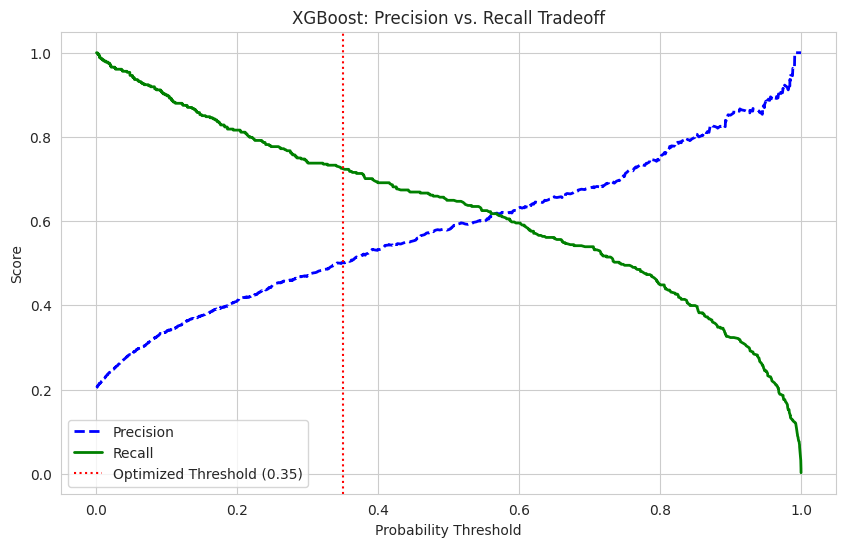

--- Results with Optimized Threshold (0.35) ---
New Recall:    0.7230
New Precision: 0.5008


In [15]:
from sklearn.metrics import precision_recall_curve, precision_score

# Get predicted probabilities for the Balanced XGBoost model
y_scores_xgb = models_proactive["XGB (Balanced)"].predict_proba(X_test_p)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_p, y_scores_xgb)

# Plotting the tradeoff
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.axvline(x=0.35, color='r', linestyle=':', label='Optimized Threshold (0.35)')
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.legend(loc="best")
plt.title("XGBoost: Precision vs. Recall Tradeoff")
plt.grid(True)
plt.show()

# Apply a custom threshold of 0.35
custom_threshold = 0.35
y_pred_custom = (y_scores_xgb >= custom_threshold).astype(int)

print(f"--- Results with Optimized Threshold (0.35) ---")
print(f"New Recall:    {recall_score(y_test_p, y_pred_custom):.4f}")
print(f"New Precision: {precision_score(y_test_p, y_pred_custom):.4f}")

## Explainable AI: SHAP Global Interpretability
To build trust with business stakeholders, we must move beyond "Black Box" models. I am using **SHAP (SHapley Additive exPlanations)** to visualize how specific features—like Age and Number of Products—directly push a customer's probability toward Churn or Retention.

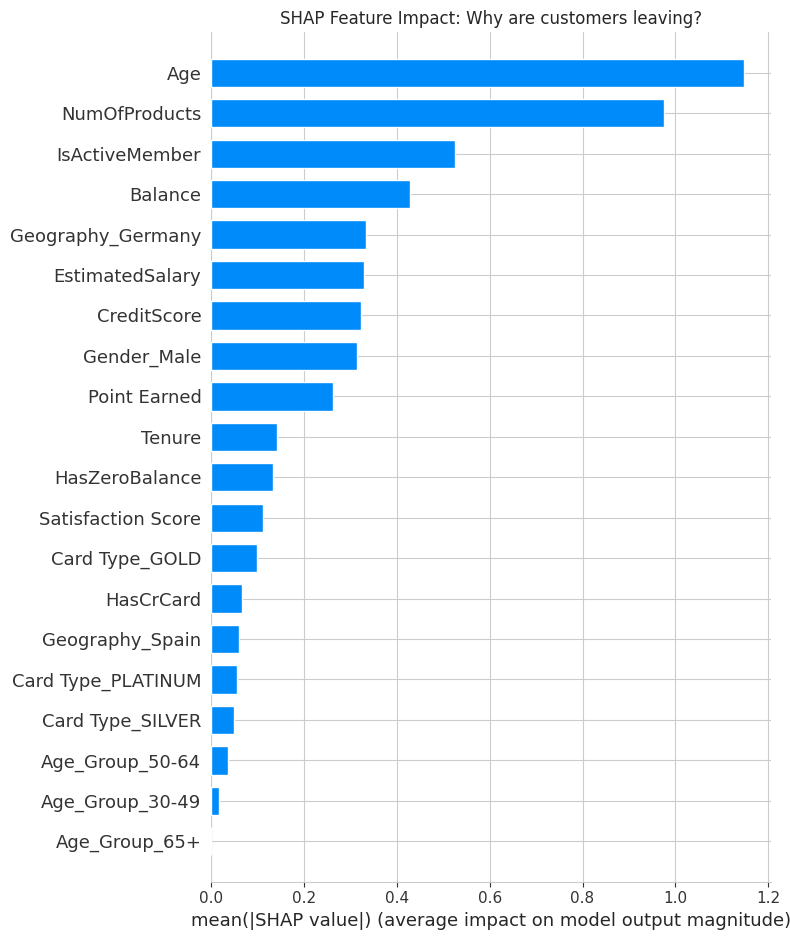

In [16]:
import shap

# Initialize the SHAP Explainer using the XGBoost model
explainer = shap.Explainer(models_proactive["XGB (Balanced)"])
shap_values = explainer(X_test_p)

# Summary plot: Highlighting the top drivers of the proactive model
plt.title("SHAP Feature Impact: Why are customers leaving?")
shap.summary_plot(shap_values, X_test_p, plot_type="bar")

# Final Summary & Strategic Insights

---

## Project Retrospective
This project involved a comprehensive analysis of 10,000 banking customers to predict churn. The journey followed a rigorous Data Science lifecycle:
* **Exploratory Data Analysis (EDA):** Uncovered non-linear relationships between demographics, account status, and churn.
* **Initial Modeling:** Built baseline models (Logistic Regression, Random Forest, XGBoost) achieving near-perfect metrics.
* **Strategic Pivot:** Diagnosed "Data Leakage" in the `Complain` feature and transitioned from a **Reactive** to a **Proactive** modeling strategy.
* **Optimization:** Implemented cost-sensitive learning (weight scaling) and threshold tuning to maximize business ROI.

---

## The Critical Turning Point: Reactive vs. Proactive
Our initial models achieved a **99.8% Accuracy**. While impressive on paper, a deep dive into feature importance revealed that the `Complain` feature was a "leaky" predictor.

> In a real banking environment, a "Complaint" is often recorded at the moment of exit. Predicting churn based on complaints is **reactive**—it tells you who is *already* leaving. By removing this feature, we forced the model to learn **behavioral precursors** to churn, creating a **Proactive Model** that identifies "silent churners" before they reach the point of no return.

---

## Key Behavioral Discoveries (EDA + SHAP)
Through our analysis and SHAP interpretability, we identified the following high-risk customer profiles:

* **The Liquidity Factor (Non-Zero Balance):** Customers with **non-zero balances** are significantly more likely to churn than those with zero balance. This suggests that customers with active funds—regardless of the amount—are more sensitive to competitor offers. Zero-balance accounts are often dormant and less likely to undergo a formal "exit" process.
* **The 50+ Risk Category:** Churn rates peak significantly in the **50–64 age group**. This demographic is likely in a life-transition phase (retirement planning) and is actively looking for the best financial stability and perks.
* **The Product "Sweet Spot":** Customers with **2 products** are the most loyal. Those with only 1 product or more than 2 products show a much higher propensity to leave, suggesting that under-engaged or over-complex relationships lead to dissatisfaction.
* **The Activity Shield:** Being an **Active Member** is the strongest behavioral deterrent against churn. Inactivity is the most reliable "silent" warning sign of an impending exit.

---

## Technical Performance Benchmarks
Our final **Balanced XGBoost** model, optimized with a custom decision threshold of **0.35**, provides the following results:

| Metric | Baseline (Proactive) | **Optimized (Proactive)** |
| :--- | :--- | :--- |
| **Recall (Catching Churners)** | 50.2% | **72.3%** |
| **Accuracy** | 85.1% | **78.4%** |
| **Business Value** | Misses half of the churn risk | **Identifies 7 out of 10 churners** |

---

**Author:** Mohammed Hussein